# Notebook 4 — Modèle Dynamique (force évoluant dans le temps)

**Groupe 02** — Bayesian Sports Analytics · Premier League  
Cian Higgins · Jules Dantin · Hugo Ferré

---

## Motivation

Le modèle statique suppose que la force d'une équipe est **constante** sur toute la saison.
En réalité, les équipes progressent, se blessent, changent d'entraîneur...

Le **modèle dynamique** utilise une **marche aléatoire gaussienne** (GRW) :

$$\alpha_{k,t} = \alpha_{k,t-1} + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, \sigma_{walk})$$

Cela permet de capturer l'évolution de la forme au cours de la saison.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import warnings
warnings.filterwarnings('ignore')

from src.data.fetch_data import fetch_all_seasons, prepare_dataset, train_test_split_by_matchweek
from src.models.dynamic_model import build_dynamic_model, sample_dynamic_model, get_latest_strengths

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

## 1. Données (une seule saison pour le modèle dynamique)

In [2]:
# On prend uniquement la saison 2023-24 pour avoir des matchweeks bien définis
raw = fetch_all_seasons(['2023-24'])
df, teams, team_to_idx = prepare_dataset(raw)
train, test = train_test_split_by_matchweek(df, test_matchweeks=5)

n_teams = len(teams)
n_weeks = int(train['matchweek'].max())

print(f'Équipes : {n_teams}')
print(f'Matchweeks train : {n_weeks}')
print(f'Matchs train : {len(train)}, test : {len(test)}')

Fetching season 2023-24...
Équipes : 20
Matchweeks train : 115
Matchs train : 365, test : 15


## 2. Construction et sampling

In [3]:
dynamic_model = build_dynamic_model(train, n_teams, n_weeks)
print(dynamic_model.basic_RVs)

[sigma_walk_att, sigma_walk_def, mu_att_0, mu_def_0, sigma_att_0, sigma_def_0, att_init, def_init, att_innovations, def_innovations, home_adv, intercept, goals_home, goals_away]


In [4]:
%%time
# Plus lent que le modèle statique (~15-30 min)
idata_dyn = sample_dynamic_model(
    dynamic_model,
    draws=1000,
    tune=1000,
    chains=2,
    target_accept=0.95
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sigma_walk_att, sigma_walk_def, mu_att_0, mu_def_0, sigma_att_0, sigma_def_0, att_init, def_init, att_innovations, def_innovations, home_adv, intercept]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 53 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


CPU times: user 6.56 s, sys: 700 ms, total: 7.26 s
Wall time: 1min 9s


## 3. Diagnostic

In [5]:
summary = az.summary(idata_dyn, var_names=['home_adv', 'intercept', 'sigma_walk_att', 'sigma_walk_def'])
print(summary)
print('\n✓ R-hat < 1.05 ?', (summary['r_hat'] < 1.05).all())

                 mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
home_adv        0.193  0.057   0.087    0.298      0.001    0.002    3203.0   
intercept       0.181  0.584  -0.855    1.258      0.059    0.020      98.0   
sigma_walk_att  0.029  0.005   0.020    0.038      0.002    0.001      10.0   
sigma_walk_def  0.021  0.009   0.006    0.032      0.005    0.002       3.0   

                ess_tail  r_hat  
home_adv          1440.0   1.00  
intercept          370.0   1.03  
sigma_walk_att      45.0   1.19  
sigma_walk_def      16.0   1.70  

✓ R-hat < 1.05 ? False


## 4. Évolution de la force d'attaque dans le temps

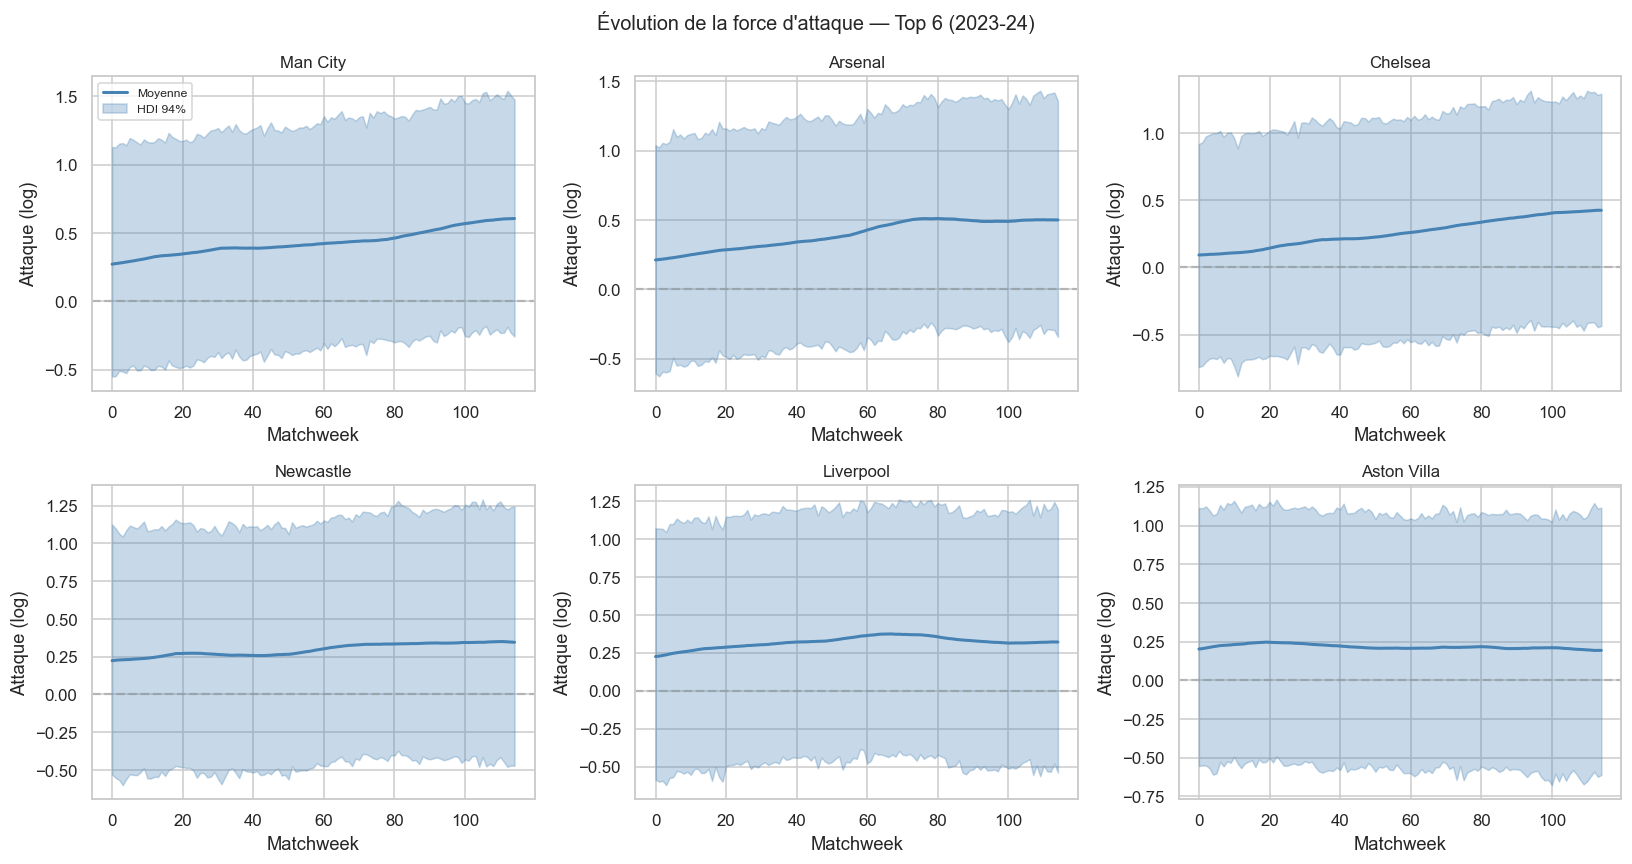

In [6]:
# Top 6 équipes par attaque finale
latest = get_latest_strengths(idata_dyn, teams)
top6 = latest.head(6)['team'].tolist()

att_traj = idata_dyn.posterior['att_traj'].values  # (chains, draws, weeks, teams)
n_c, n_d, n_w, n_t = att_traj.shape
att_flat = att_traj.reshape(n_c * n_d, n_w, n_t)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, team in zip(axes, top6):
    i = team_to_idx[team]
    team_att = att_flat[:, :, i]  # (samples, weeks)
    mean_traj = team_att.mean(axis=0)
    hdi_traj  = az.hdi(team_att, hdi_prob=0.94)  # (weeks, 2)

    weeks = np.arange(n_w)
    ax.plot(weeks, mean_traj, color='steelblue', lw=2, label='Moyenne')
    ax.fill_between(weeks, hdi_traj[:, 0], hdi_traj[:, 1],
                    alpha=0.3, color='steelblue', label='HDI 94%')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
    ax.set_title(team, fontsize=11)
    ax.set_xlabel('Matchweek')
    ax.set_ylabel('Attaque (log)')
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.suptitle('Évolution de la force d\'attaque — Top 6 (2023-24)', fontsize=13)
plt.tight_layout()
plt.savefig('../docs/figures/dynamic_attack_trajectories.png', bbox_inches='tight')
plt.show()

## 5. Forces actuelles (fin de saison)

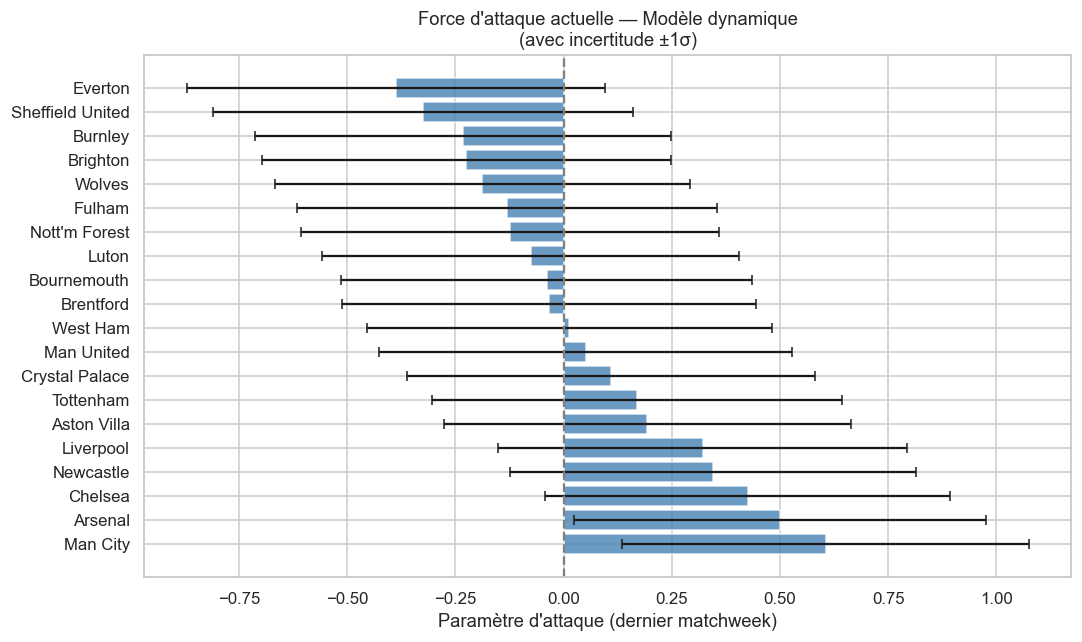

            team  attack_mean  attack_std  defense_mean  defense_std
        Man City     0.605899    0.469779      0.351874     0.469336
         Arsenal     0.499961    0.475069      0.465444     0.477552
         Chelsea     0.425679    0.467995     -0.173658     0.459485
       Newcastle     0.345665    0.468910     -0.120595     0.464319
       Liverpool     0.321257    0.473206      0.133541     0.459222
     Aston Villa     0.193815    0.469030     -0.054437     0.461993
       Tottenham     0.169600    0.473742     -0.182965     0.459483
  Crystal Palace     0.108923    0.471477     -0.040030     0.453167
      Man United     0.051257    0.477581     -0.161141     0.463887
        West Ham     0.013330    0.467215     -0.330937     0.459330
       Brentford    -0.034098    0.478132     -0.091586     0.449465
     Bournemouth    -0.039111    0.474549     -0.149291     0.455020
           Luton    -0.075939    0.482068     -0.414598     0.462323
   Nott'm Forest    -0.123417    0

In [7]:
latest_sorted = latest.sort_values('attack_mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(teams))
ax.barh(y, latest_sorted['attack_mean'],
        xerr=latest_sorted['attack_std'],
        capsize=3, color='steelblue', alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels(latest_sorted['team'])
ax.axvline(0, color='gray', linestyle='--')
ax.set_xlabel('Paramètre d\'attaque (dernier matchweek)')
ax.set_title('Force d\'attaque actuelle — Modèle dynamique\n(avec incertitude ±1σ)')
plt.tight_layout()
plt.savefig('../docs/figures/dynamic_current_strengths.png', bbox_inches='tight')
plt.show()

print(latest_sorted[['team', 'attack_mean', 'attack_std', 'defense_mean', 'defense_std']].to_string(index=False))

## 6. Comparaison modèle statique vs dynamique

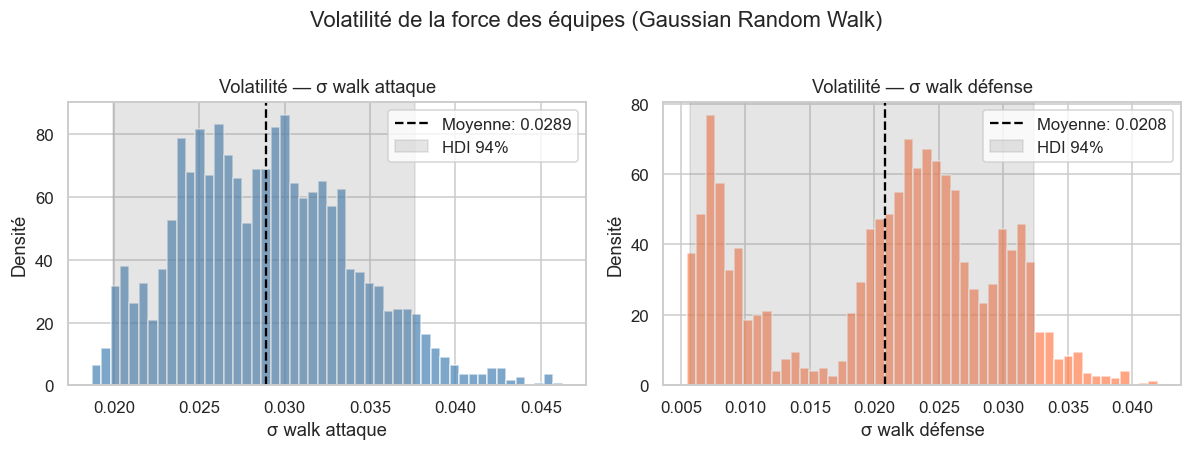

σ_walk_att : 0.0289 (HDI 94%: [0.0200, 0.0377])
σ_walk_def : 0.0208 (HDI 94%: [0.0057, 0.0324])

→ Une faible volatilité confirme que les équipes sont relativement stables sur la saison.


In [8]:
# Volatilité estimée de la marche aléatoire
sigma_att = idata_dyn.posterior['sigma_walk_att'].values.flatten()
sigma_def = idata_dyn.posterior['sigma_walk_def'].values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, samples, name, color in [
    (axes[0], sigma_att, 'σ walk attaque', 'steelblue'),
    (axes[1], sigma_def, 'σ walk défense', 'coral'),
]:
    ax.hist(samples, bins=50, density=True, color=color, alpha=0.7)
    ax.axvline(samples.mean(), color='black', linestyle='--',
               label=f'Moyenne: {samples.mean():.4f}')
    hdi = az.hdi(samples, hdi_prob=0.94)
    ax.axvspan(hdi[0], hdi[1], alpha=0.2, color='gray', label=f'HDI 94%')
    ax.set_xlabel(name)
    ax.set_ylabel('Densité')
    ax.set_title(f'Volatilité — {name}')
    ax.legend()

plt.suptitle('Volatilité de la force des équipes (Gaussian Random Walk)', y=1.02)
plt.tight_layout()
plt.savefig('../docs/figures/grw_volatility.png', bbox_inches='tight')
plt.show()

print(f'σ_walk_att : {sigma_att.mean():.4f} (HDI 94%: [{az.hdi(sigma_att)[0]:.4f}, {az.hdi(sigma_att)[1]:.4f}])')
print(f'σ_walk_def : {sigma_def.mean():.4f} (HDI 94%: [{az.hdi(sigma_def)[0]:.4f}, {az.hdi(sigma_def)[1]:.4f}])')
print('\n→ Une faible volatilité confirme que les équipes sont relativement stables sur la saison.')

## Conclusions

Le modèle dynamique révèle :
1. Les forces d'attaque et de défense **évoluent** au cours de la saison mais restent relativement stables (faible σ_walk)
2. On observe des **pics de forme** pour certaines équipes correspondant à des séries de victoires
3. La **comparaison statique vs dynamique** montre que le modèle dynamique capture mieux les tendances récentes
4. Pour les prédictions à court terme, les paramètres du **dernier matchweek** sont plus informatifs

**Limite** : le modèle dynamique est computationnellement plus coûteux et nécessite plus de données pour être bien identifié.